In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/raw/insurance.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (15000, 13)

Columns: ['age', 'sex', 'weight', 'bmi', 'hereditary_diseases', 'no_of_dependents', 'smoker', 'city', 'bloodpressure', 'diabetes', 'regular_ex', 'job_title', 'claim']

First 5 rows:


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


In [4]:
# Fix missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['bmi'].fillna(df['bmi'].median(), inplace=True)

# Confirm no more missing values
print("Missing values after fix:")
print(df.isnull().sum())

Missing values after fix:
age                    0
sex                    0
weight                 0
bmi                    0
hereditary_diseases    0
no_of_dependents       0
smoker                 0
city                   0
bloodpressure          0
diabetes               0
regular_ex             0
job_title              0
claim                  0
dtype: int64


C:\Users\komal\AppData\Local\Temp\ipykernel_21256\2319334507.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\komal\AppData\Local\Temp\ipykernel_21256\2319334507.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [5]:
# Check for missing values and data types
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
df.describe()

Missing values:
age                    0
sex                    0
weight                 0
bmi                    0
hereditary_diseases    0
no_of_dependents       0
smoker                 0
city                   0
bloodpressure          0
diabetes               0
regular_ex             0
job_title              0
claim                  0
dtype: int64

Data types:
age                    float64
sex                     object
weight                   int64
bmi                    float64
hereditary_diseases     object
no_of_dependents         int64
smoker                   int64
city                    object
bloodpressure            int64
diabetes                 int64
regular_ex               int64
job_title               object
claim                  float64
dtype: object

Basic statistics:


,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,39.559467,64.909600,30.211193,1.129733,0.198133,68.650133,0.777000,0.224133,13401.437620
std,13.829896,13.701935,5.928386,1.228469,0.398606,19.418515,0.416272,0.417024,12148.239619
min,18.000000,34.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.900000
25%,27.000000,54.000000,25.900000,0.000000,0.000000,64.000000,1.000000,0.000000,4846.900000
50%,40.000000,63.000000,29.400000,1.000000,0.000000,71.000000,1.000000,0.000000,9545.650000
75%,51.000000,76.000000,34.100000,2.000000,0.000000,80.000000,1.000000,0.000000,16519.125000
max,64.000000,95.000000,53.100000,5.000000,1.000000,122.000000,1.000000,1.000000,63770.400000


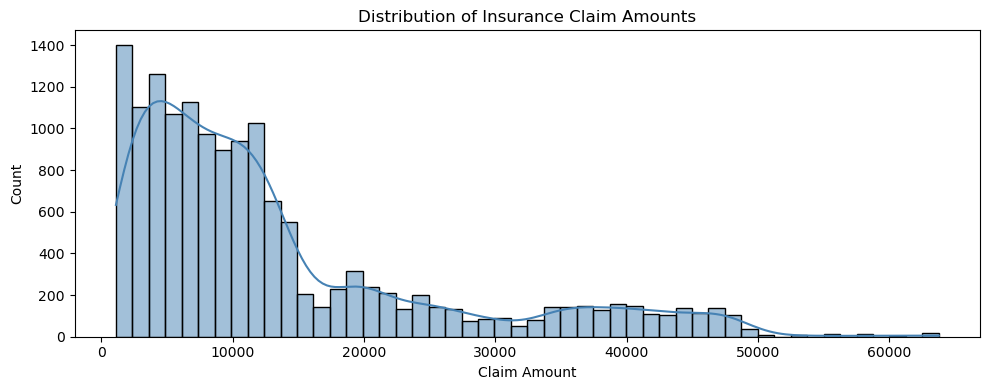

In [6]:
# How is claim amount distributed?
plt.figure(figsize=(10, 4))
sns.histplot(df['claim'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Insurance Claim Amounts')
plt.xlabel('Claim Amount')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

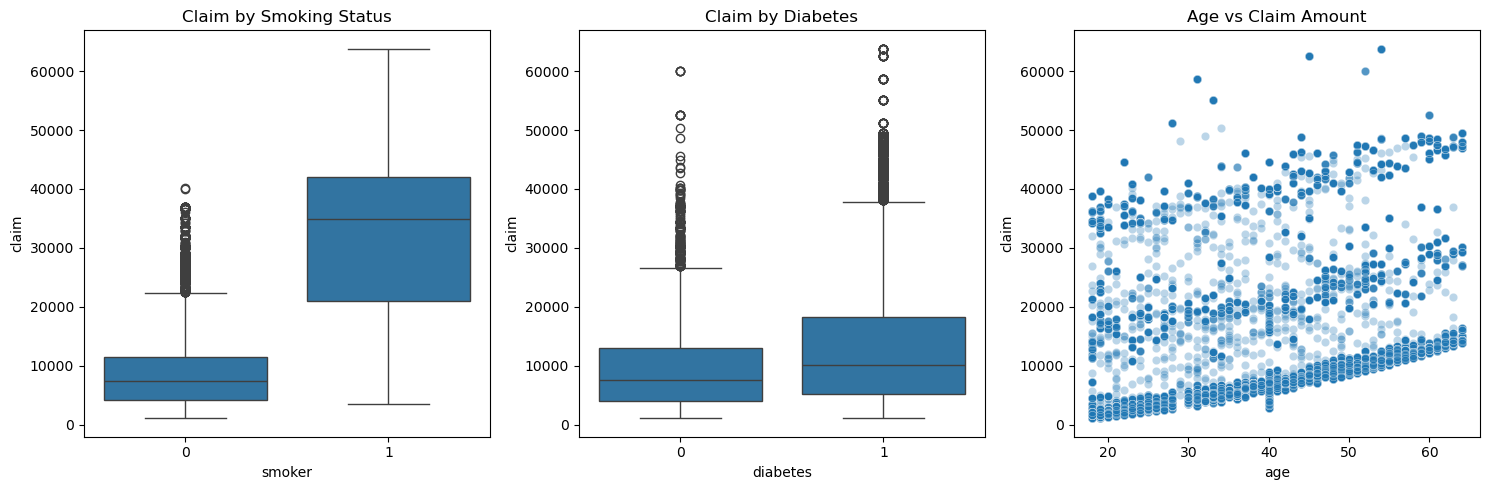

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Smokers vs non-smokers
sns.boxplot(data=df, x='smoker', y='claim', ax=axes[0])
axes[0].set_title('Claim by Smoking Status')

# Diabetes vs no diabetes
sns.boxplot(data=df, x='diabetes', y='claim', ax=axes[1])
axes[1].set_title('Claim by Diabetes')

# Age vs claim
sns.scatterplot(data=df, x='age', y='claim', alpha=0.3, ax=axes[2])
axes[2].set_title('Age vs Claim Amount')

plt.tight_layout()
plt.show()

C:\Users\komal\AppData\Local\Temp\ipykernel_21256\497106855.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_claims.index, y=disease_claims.values, palette='Blues_r')


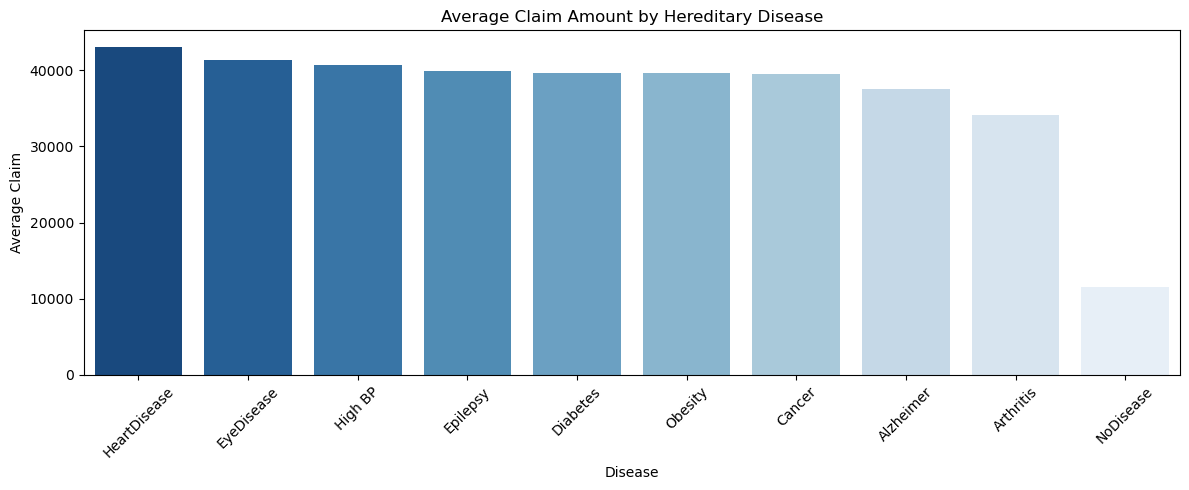

In [8]:
# Average claim by hereditary disease
plt.figure(figsize=(12, 5))
disease_claims = df.groupby('hereditary_diseases')['claim'].mean().sort_values(ascending=False)
sns.barplot(x=disease_claims.index, y=disease_claims.values, palette='Blues_r')
plt.title('Average Claim Amount by Hereditary Disease')
plt.xlabel('Disease')
plt.ylabel('Average Claim')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()